# **Step 1: Data Loading & Understanding**

In [ ]:
import pandas as pd

In [4]:
import pandas as pd
df=pd.read_excel("/content/Online Retail.xlsx")

In [5]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [6]:
df.shape

(541909, 8)

In [8]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [10]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


# **Step 2: Data Cleaning & Preparation**

In [11]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 5268


In [12]:
df = df[df["Quantity"] > 0]
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [13]:
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int)

In [14]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [15]:
customer_df = df.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "TotalPrice": "sum",
    "UnitPrice": "mean"
}).reset_index()

In [16]:
customer_df.columns = [
    "CustomerID",
    "Frequency",
    "TotalQuantity",
    "TotalSpending",
    "AvgUnitPrice"
]

In [17]:
from sklearn.preprocessing import StandardScaler
features = ["Frequency", "TotalQuantity", "TotalSpending", "AvgUnitPrice"]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_df[features])

# **Step 3: Exploratory Data Analysis**

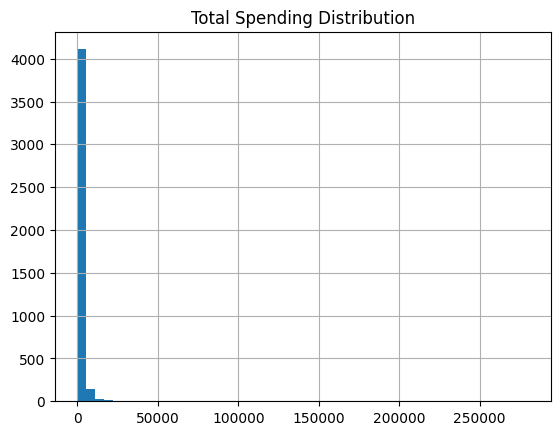

In [18]:
import matplotlib.pyplot as plt
plt.figure()
customer_df["TotalSpending"].hist(bins=50)
plt.title("Total Spending Distribution")
plt.show()

In [19]:
customer_df[features].skew()

,0
Frequency,12.100028
TotalQuantity,20.401587
TotalSpending,19.341403
AvgUnitPrice,50.238222


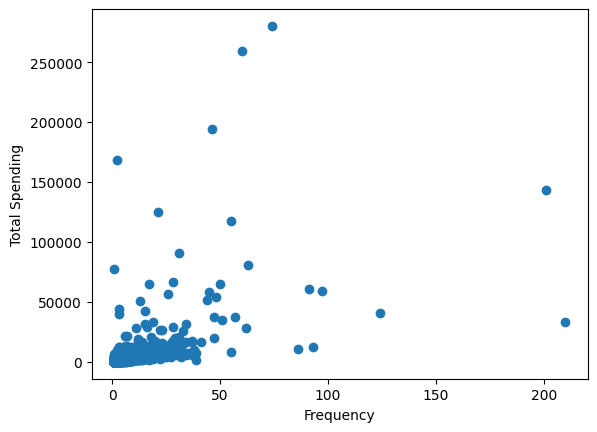

In [20]:
plt.figure()
plt.scatter(customer_df["Frequency"], customer_df["TotalSpending"])
plt.xlabel("Frequency")
plt.ylabel("Total Spending")
plt.show()

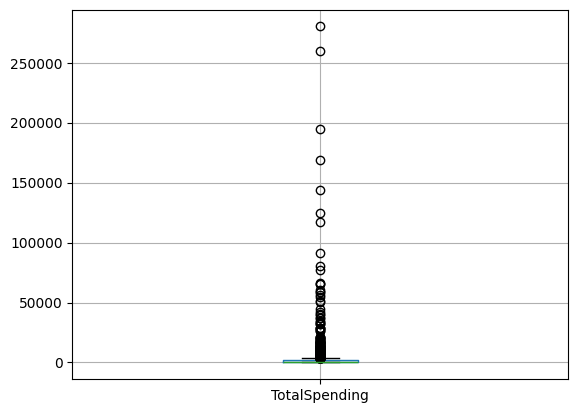

In [21]:
plt.figure()
customer_df.boxplot(column="TotalSpending")
plt.show()

# **Step 4: K-Means Clustering**

In [22]:
from sklearn.cluster import KMeans

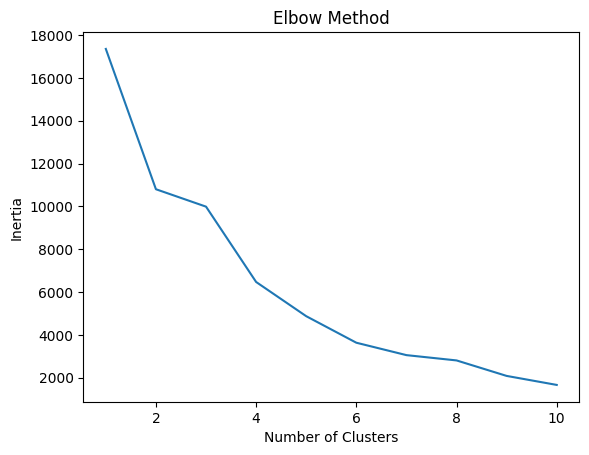

In [24]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)
plt.figure()
plt.plot(range(1,11), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [25]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.9591740170631239
K=3, Silhouette Score=0.9550213862881977
K=4, Silhouette Score=0.9557448174167187
K=5, Silhouette Score=0.9212865671236757
K=6, Silhouette Score=0.7661068564408874
K=7, Silhouette Score=0.7613765475479405
K=8, Silhouette Score=0.6511516943321941
K=9, Silhouette Score=0.6588885540397893


In [26]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
customer_df["Cluster"] = kmeans.fit_predict(scaled_features)

In [27]:
cluster_summary = customer_df.groupby("Cluster")[features].mean()
print(cluster_summary)

          Frequency  TotalQuantity  TotalSpending  AvgUnitPrice
Cluster                                                        
0          3.976604     914.165856    1567.604008      3.999565
1         46.277778   60601.055556  105585.838333      4.384577
2        178.333333   42870.666667   72428.066667      3.272798
3          1.000000       1.000000    2033.100000   2033.100000


# **Step 5: Hierarchical Clustering**

In [28]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
customer_df["H_Cluster"] = agg.fit_predict(scaled_features)

In [29]:
for method in ["ward", "complete", "average"]:
    agg = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels = agg.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    print(method, score)

ward 0.9442871980430896
complete 0.960888389031367
average 0.9703155574125818


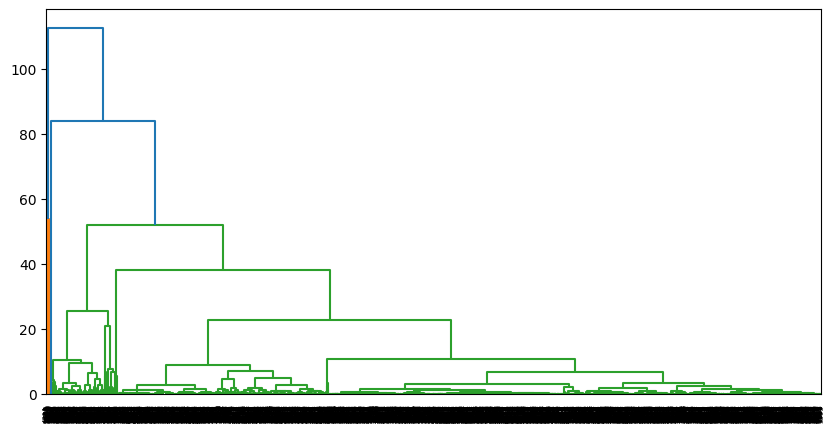

In [30]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(scaled_features, method="ward")
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.show()

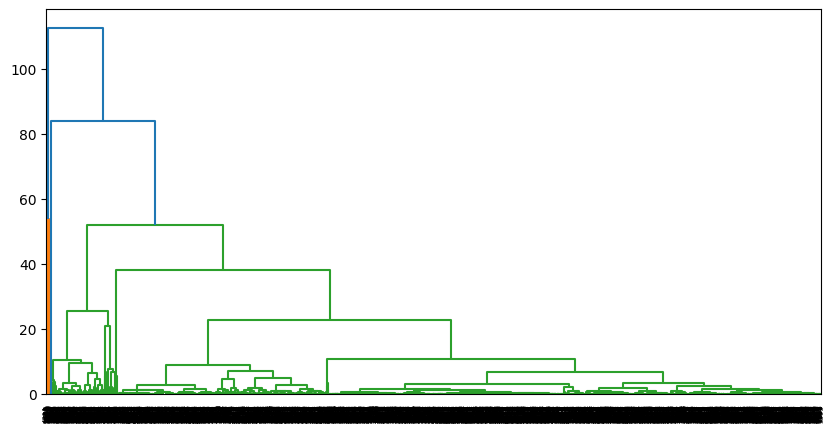

In [31]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(scaled_features, method="ward")
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.show()